<a href="https://colab.research.google.com/github/vidyasreepatil67-sys/Student-Performance-Prediction/blob/main/Student_Performance_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import libraries


In [ ]:
import pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

Create the Student datset

In [ ]:
data = {
    'Study_Hours': [2, 5, 7, 1, 6, 3, 8, 2, 5, 7,
                    4, 1, 6, 3, 8, 2, 7, 5, 4, 9],

    'Attendance': [60, 80, 90, 50, 85, 65, 95, 55, 82, 92,
                   75, 45, 88, 62, 96, 58, 91, 84, 70, 98],

    'Previous_Marks': [45, 65, 80, 35, 72, 50, 88, 40, 70, 85,
                       60, 30, 78, 48, 90, 42, 82, 75, 55, 95],

    'Assignment_Marks': [50, 70, 85, 40, 75, 55, 90, 45, 72, 88,
                         65, 35, 80, 50, 92, 48, 87, 78, 60, 96],

    'Result': ['Fail', 'Pass', 'Pass', 'Fail', 'Pass',
               'Fail', 'Pass', 'Fail', 'Pass', 'Pass',
               'Pass', 'Fail', 'Pass', 'Fail', 'Pass',
               'Fail', 'Pass', 'Pass', 'Pass', 'Pass']
}
df = pd.DataFrame(data)

print(df)

Separate features and target

In [ ]:
X=df[['Study_Hours', 'Attendance', 'Previous_Marks', 'Assignment_Marks']]
y=df['Result']

Split the dataset

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

Decsion Tree Classifier

In [ ]:
dt_model=DecisionTreeClassifier(criterion='gini',max_depth=3,random_state=42)
dt_model.fit(X_train,y_train)
y_pred_dt=dt_model.predict(X_test)
accuracy_dt=accuracy_score(y_test,y_pred_dt)
print("Decision Tree Accuracy:",accuracy_dt)
print(classification_report(y_test,y_pred_dt))

Decision Tree Accuracy: 1.0
              precision    recall  f1-score   support

        Fail       1.00      1.00      1.00         2
        Pass       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



Plot the Decision Tree

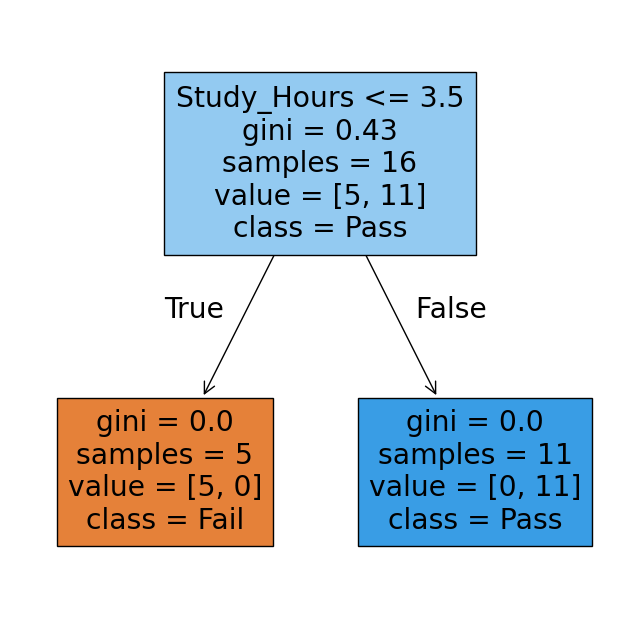

In [ ]:
plt.figure(figsize=(8,8))
plot_tree(dt_model,feature_names=X.columns,class_names=dt_model.classes_,filled=True)
plt.show()

Random Forest Classifier

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

        Fail       1.00      1.00      1.00         2
        Pass       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



Feature Importance

In [ ]:
importance = rf_model.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)
print(feature_importance)

            Feature  Importance
1        Attendance        0.29
0       Study_Hours        0.25
2    Previous_Marks        0.24
3  Assignment_Marks        0.22


Plot Feature Importance

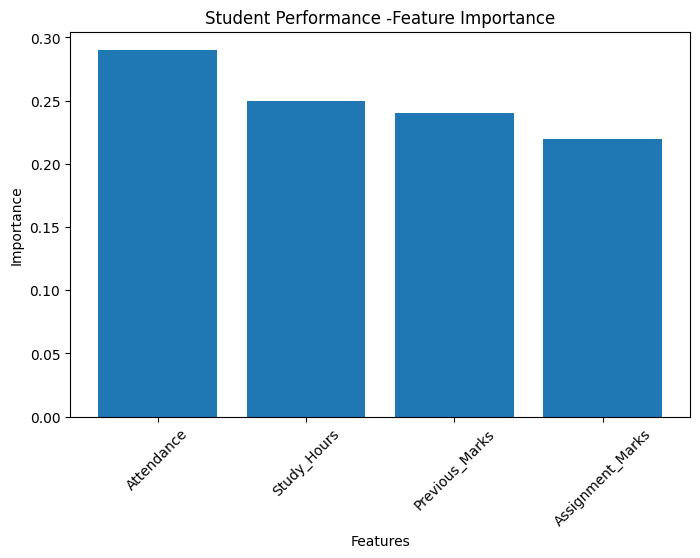

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Student Performance -Feature Importance")
plt.xticks(rotation=45)
plt.show()